## **Exercice 1**

# **Description des variables du dataset titanic :**  
## **Variables Cible et Catégorielles :**
**Survived** : Variable cible. Indique si le passager a survécu (0 = Non, 1 = Oui )).  
**Pclass** : Classe du billet. Utilisé comme indicateur du statut socio-économique :
* 1 = 1ère classe (Haute)
* 2 = 2ème classe (Moyenne)
* 3 = 3ème classe (Basse)


**Sex** : Sexe du passager (male ou female).  
**Embarked** : Port d'embarquement (C = Cherbourg, Q = Queenstown, S = Southampton).  
**Cabin** : Numéro de cabine du passager (contient souvent des valeurs manquantes).
## **Variables Numériques**
**Age** : Âge du passager en années. Les âges inférieurs à 1 an sont exprimés en décimales (ex: 0.42). Contient des valeurs manquantes.  
**Fare** : Tarif du billet payé en livres sterling.  
**SibSp** : Nombre de frères/sœurs ou conjoints (époux/épouse) également à bord.  
**Parch** : Nombre de parents (père/mère) ou d'enfants également à bord.
## **Variables d'IdentificationPassenger**  
**Id** : Identifiant unique assigné à chaque passager.  
**Name** : Nom complet du passager (inclut souvent les titres comme M., Mrs., Miss.).  
**Ticket** : Numéro de ticket du passager.

In [36]:
import pandas as pd


In [37]:
df = pd.read_csv('train.csv')

In [38]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [40]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=2)
df['Age'] = imputer.fit_transform(df[['Age']])

In [41]:
df['Age'] = df['Age'].astype(int)

In [42]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [43]:
df = df[df['Embarked'].notnull()]

In [44]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [45]:
df['Cabin'] = df['Cabin'].fillna('Non renseigné')

In [46]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [47]:
df['Fare'].head()

,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500


In [48]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

scaler = MinMaxScaler()
df['Fare'] = scaler.fit_transform(df[['Fare']])

In [49]:
standard_scaler = StandardScaler()
df['Age'] = standard_scaler.fit_transform(df[['Age']])

In [50]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,-0.578023,1,0,A/5 21171,0.014151,Non renseigné,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.655371,1,0,PC 17599,0.139136,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,-0.269675,0,0,STON/O2. 3101282,0.015469,Non renseigné,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.424109,1,0,113803,0.103644,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,0.424109,0,0,373450,0.015713,Non renseigné,S


Généralement les modèles ont tendance à priorisér les grandes valeurs pour faire leur prédiction, ce qui que entrainer de fois résultats non attendu, donc il est essentielle de normaliser ou de stantadilisé les données afin de réduire leur échelle et d'améliorer les prédictions des modèles.

## **Exercice 2**

In [51]:
#Family size
df['family_size'] = df['SibSp'] + df['Parch'] + 1

In [52]:
#is_alone to verify if passengers is alone
def is_alone(family_size): # 1  --> il est seul, 0 il
    if family_size == 1:
        return 1
    else:
        return 0

In [53]:
df['is_alone'] = df['family_size'].apply(is_alone)

In [54]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,-0.578023,1,0,A/5 21171,0.014151,Non renseigné,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.655371,1,0,PC 17599,0.139136,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,-0.269675,0,0,STON/O2. 3101282,0.015469,Non renseigné,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.424109,1,0,113803,0.103644,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,0.424109,0,0,373450,0.015713,Non renseigné,S,1,1


In [55]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,340


In [56]:
len(df[(df['family_size'] > 1) &( df['Survived'] == 1)])

179

In [57]:
len(df[(df['family_size'] > 2) &( df['Survived'] == 1)])

90

In [58]:
len(df[(df['family_size'] > 3) &( df['Survived'] == 1)])

31

On constate que plus la famille devient nombreuse, le nombre de survie diminue

In [59]:
len(df[(df['is_alone']==1) & (df['Survived']==0)])

374

In [60]:
len(df[(df['is_alone']==1) & (df['Survived']==1)])

161

On remarque que 374 passagers sont mort lorsqu'il voyageait seul et 161 ont survécu en étant seul.  
On peut en conclure que les passagers étant seul on plus de chance de mourir que ceux étant accompagné

## **Exercice 3**

In [61]:
df_train = pd.read_csv('train.csv')

Normalisation MinMax --> s''utilise sur les caractéristique asymétrique comme le prix (Fare)  
Normalisation par le Z score (StandartScaler)  --> s'utilise sur des caractéristiques distribué comme age

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

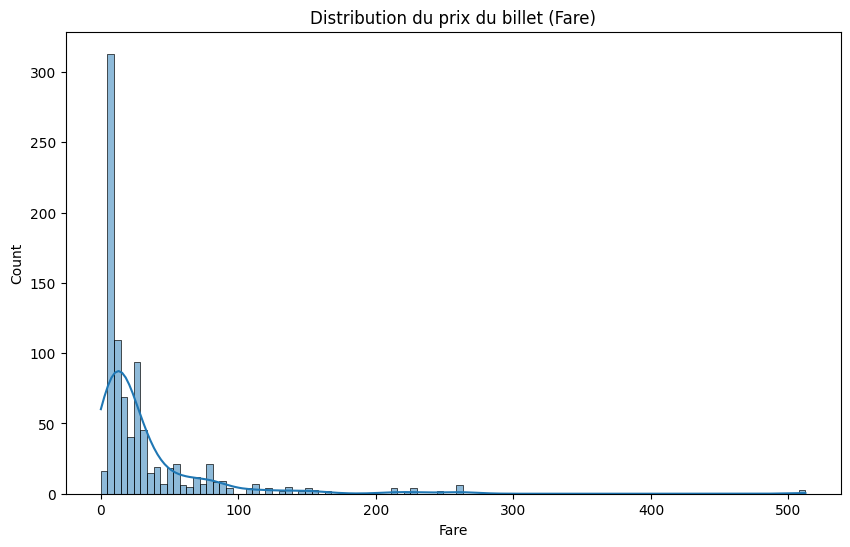

In [66]:
plt.figure(figsize=(10,6))
sns.histplot(df_train['Fare'],kde=True)
plt.title('Distribution du prix du billet (Fare)')
plt.show()

On observe une distribution qui n'est pas concentré, ce qui peut fausser le calcule de ma moyenne

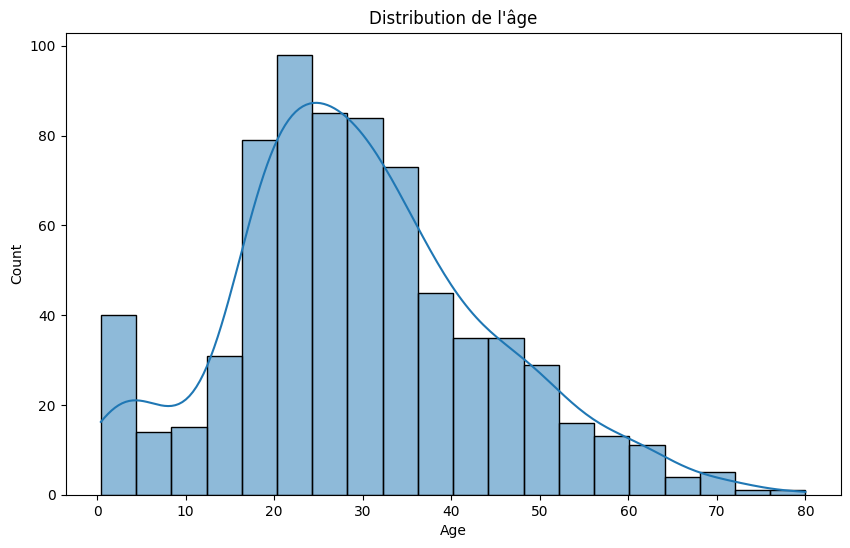

In [67]:
plt.figure(figsize=(10,6))
sns.histplot(df_train['Age'],kde=True)
plt.title('Distribution de l\'âge')
plt.show()

In [68]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

scaler = MinMaxScaler()
df_train['Fare'] = scaler.fit_transform(df_train[['Fare']])

In [69]:
standard_scaler = StandardScaler()
df_train['Age'] = standard_scaler.fit_transform(df_train[['Age']])

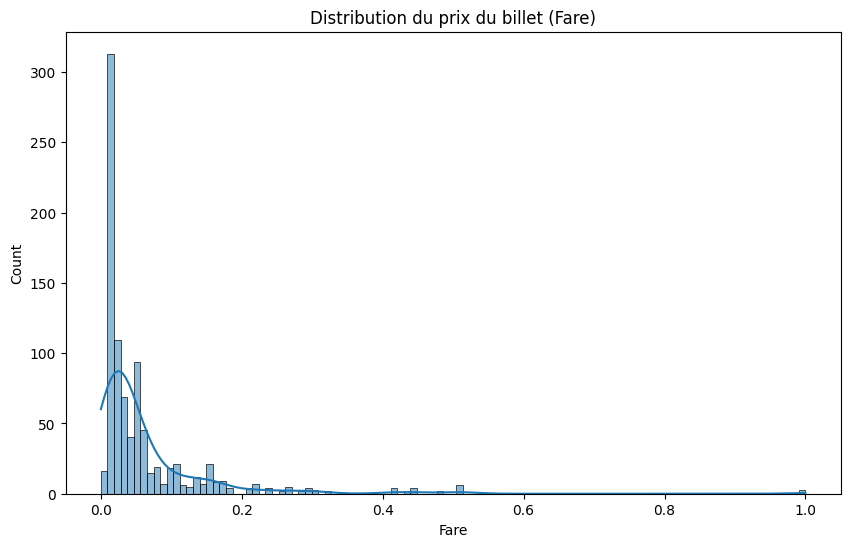

In [70]:
plt.figure(figsize=(10,6))
sns.histplot(df_train['Fare'],kde=True)
plt.title('Distribution du prix du billet (Fare)')
plt.show()

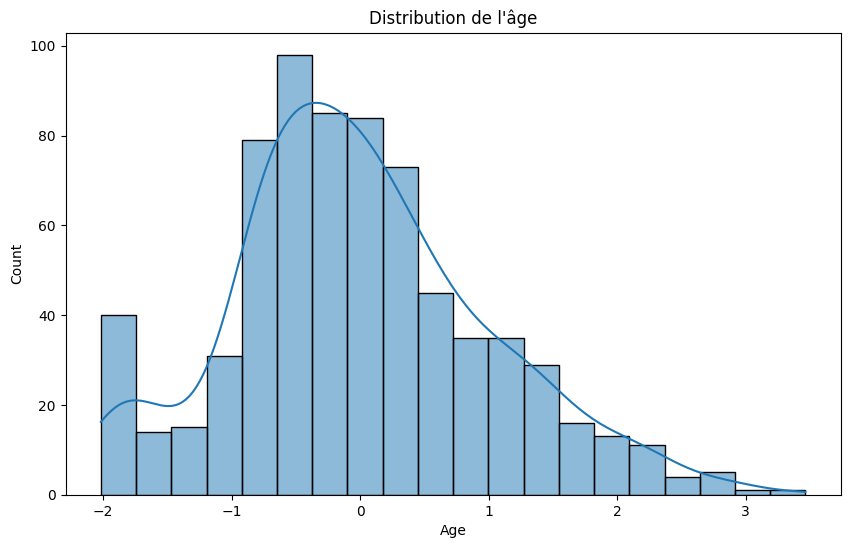

In [71]:
plt.figure(figsize=(10,6))
sns.histplot(df_train['Age'],kde=True)
plt.title('Distribution de l\'âge')
plt.show()

Avant la normalisation les données était très disperser car il y a des valeurs très grande par rapport à d'autre, ce qui peut pertuber les algorithme de machine learning  
Après la normalisation, toutes les valeurs sont raménées dans les plage de 0 à 1 et deviennent facile à traiter pour les modèles

## **Exercice 4**

In [72]:
#Utilisations de l'ACP pour réduire les dimensions
from sklearn.decomposition import PCA

In [79]:
acp = PCA(n_components=2)
acp_reduction =  acp.fit_transform(df[['Fare','Age']])

In [80]:
new_dataframe = pd.DataFrame(data=acp_reduction,columns=['PC1','PC2'])

In [84]:
new_dataframe.head()

,PC1,PC2
0,-0.578432,-0.043355
1,0.656025,0.070655
2,-0.270084,-0.044780
3,0.424457,0.037222
4,0.423675,-0.050706


In [90]:
#Regroupement des données
df.groupby('Survived')['Fare'].mean()

,Fare
Survived,
0,0.043171
1,0.094099


Ce qui ont survécu on payé en moyenne 0.09$

In [91]:
df.groupby('Survived')['Fare'].sum()

,Fare
Survived,
0,23.701011
1,31.993549


La somme payé par ce qui ont survécu est supérieure à ceux qui sont mort

In [94]:
df.groupby('Survived')['Fare'].std()

,Fare
Survived,
0,0.061266
1,0.130285


In [95]:
df.groupby('Sex')['Fare'].mean()

,Fare
Sex,
female,0.086374
male,0.049819


Les femmes ont payé en moyenne plus que les hommes (0.08)

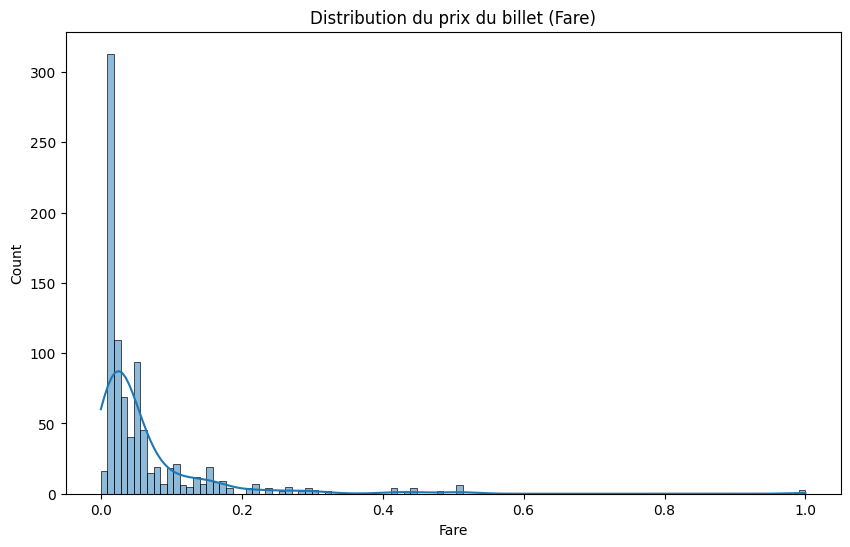

In [97]:
plt.figure(figsize=(10,6))
sns.histplot(df['Fare'],kde=True)
plt.title('Distribution du prix du billet (Fare)')
plt.show()

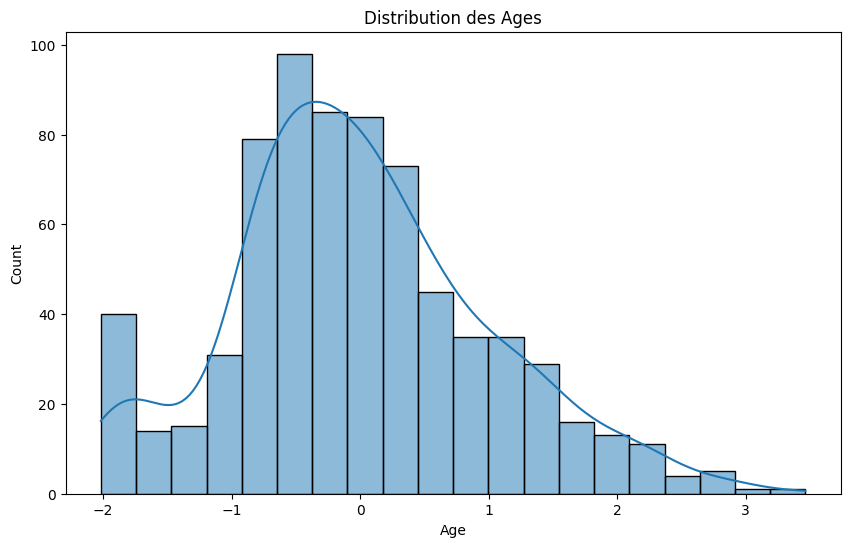

In [98]:
plt.figure(figsize=(10,6))
sns.histplot(df_train['Age'],kde=True)
plt.title('Distribution des Ages')
plt.show()

## **Exercice 5**

In [110]:
df_superstore = pd.read_csv('superstore_dataset2011-2015.csv', encoding='latin1')

In [111]:
df_superstore.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,42433,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,...,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium
1,22253,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium
2,48883,HU-2011-1220,1/1/2011,5/1/2011,Second Class,AT-735,Annie Thurman,Consumer,Budapest,Budapest,...,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640,8.17,High
3,11731,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,EM-14140,Eugene Moren,Home Office,Stockholm,Stockholm,...,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055,4.82,High
4,22255,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770,4.70,Medium


In [112]:
df_superstore.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [113]:
df_superstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [114]:
df_superstore.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [115]:
df_superstore = df_superstore.drop('Postal Code',axis=1)

In [116]:
df_superstore.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [117]:
df_superstore['Sales_normalized'] = scaler.fit_transform(df_superstore[['Sales']])
df_superstore['Profit_normalized'] = scaler.fit_transform(df_superstore[['Profit']])

In [118]:
df_superstore.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Sales_normalized,Profit_normalized
0,42433,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,...,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium,0.018016,0.447076
1,22253,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium,0.005297,0.442402
2,48883,HU-2011-1220,1/1/2011,5/1/2011,Second Class,AT-735,Annie Thurman,Consumer,Budapest,Budapest,...,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640,8.17,High,0.002901,0.441976
3,11731,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,EM-14140,Eugene Moren,Home Office,Stockholm,Stockholm,...,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055,4.82,High,0.001962,0.438263
4,22255,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770,4.70,Medium,0.005002,0.442518
